In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
class CardsDataset(Dataset):
    def __init__(self, damaged_path, normal_path, transform=None, limit_each=144):
        self.transform = transform
        self.images = []
        self.labels = []

        # Cargar dañadas = 1
        damaged_files = os.listdir(damaged_path)[:limit_each]
        for file in damaged_files:
            path = os.path.join(damaged_path, file)
            self.images.append(path)
            self.labels.append(1)

        # Cargar normales = 0
        normal_files = os.listdir(normal_path)[:limit_each]
        for file in normal_files:
            path = os.path.join(normal_path, file)
            self.images.append(path)
            self.labels.append(0)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(self.images[idx]).convert("L")
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label


In [3]:
from torchvision import transforms

# -----------------------------
# TRANSFORMACIONES + AUGMENTATION
# -----------------------------
transform = transforms.Compose([
    transforms.Resize((227, 227)),      # Tamaño correcto para AlexNet
    transforms.RandomRotation(5),       # Aumento 1: Rotación leve
    transforms.RandomHorizontalFlip(),  # Aumento 2: Flip horizontal
    transforms.ToTensor(),              
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalización
])

In [4]:
DAMAGED_PATH = r"C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN"
NORMAL_PATH  = r"C:\Users\Sebastian\Desktop\PruebaModelAlexNet\normalN-20251125T140847Z-1-001\normalN"

print("Ruta dañadas:", DAMAGED_PATH)
print("Ruta normales:", NORMAL_PATH)

assert os.path.exists(DAMAGED_PATH), "Carpeta dañadas no encontrada"
assert os.path.exists(NORMAL_PATH), "Carpeta normales no encontrada"


Ruta dañadas: C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN
Ruta normales: C:\Users\Sebastian\Desktop\PruebaModelAlexNet\normalN-20251125T140847Z-1-001\normalN


In [5]:
dataset = CardsDataset(
    damaged_path=DAMAGED_PATH,
    normal_path=NORMAL_PATH,
    transform=transform,
    limit_each=144
)

print(f"Total imágenes cargadas: {len(dataset)}")

train_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True
)

print("Loader OK ✔")

Total imágenes cargadas: 288
Loader OK ✔


In [6]:
class AlexNetModified(nn.Module):
    def __init__(self, num_classes=2):
        super(AlexNetModified, self).__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=11, stride=4, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(64, 192, kernel_size=5, padding=2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((6, 6))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(),
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.adaptive_pool(x)
        x = self.classifier(x)
        return x

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim

# -----------------------------
# DEVICE
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando device:", device)

# -----------------------------
# MODELO
# -----------------------------
model = AlexNetModified(num_classes=2).to(device)

# -----------------------------
# HIPERPARÁMETROS
# -----------------------------
learning_rate = 0.0001
num_epochs = 12
batch_size = 16    

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

loss_values = []

print("Entrenando modelo...\n")

Usando device: cpu
Entrenando modelo...



In [8]:
from torch.utils.data import random_split, DataLoader

# Tamaños de los splits
total_size = len(dataset)
train_size = int(0.7 * total_size)
val_size   = int(0.15 * total_size)
test_size  = total_size - train_size - val_size

train_dataset, val_dataset, test_dataset = random_split(
    dataset,
    [train_size, val_size, test_size]
)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [9]:
train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    # ---------------------------
    # ENTRENAMIENTO
    # ---------------------------
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ---------------------------
    # VALIDACIÓN
    # ---------------------------
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_loss /= len(val_loader)
    val_accuracy = correct / total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs} | "
          f"Train Loss: {epoch_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Val Acc: {val_accuracy*100:.2f}%")

Epoch 1/12 | Train Loss: 0.6910 | Val Loss: 0.6615 | Val Acc: 62.79%
Epoch 2/12 | Train Loss: 0.6597 | Val Loss: 0.7247 | Val Acc: 46.51%
Epoch 3/12 | Train Loss: 0.6256 | Val Loss: 0.6051 | Val Acc: 72.09%
Epoch 4/12 | Train Loss: 0.6067 | Val Loss: 0.5769 | Val Acc: 74.42%
Epoch 5/12 | Train Loss: 0.5550 | Val Loss: 0.5482 | Val Acc: 79.07%
Epoch 6/12 | Train Loss: 0.4803 | Val Loss: 0.7003 | Val Acc: 69.77%
Epoch 7/12 | Train Loss: 0.4056 | Val Loss: 0.5994 | Val Acc: 74.42%
Epoch 8/12 | Train Loss: 0.3942 | Val Loss: 0.5680 | Val Acc: 65.12%
Epoch 9/12 | Train Loss: 0.4731 | Val Loss: 0.5225 | Val Acc: 74.42%
Epoch 10/12 | Train Loss: 0.3222 | Val Loss: 0.5455 | Val Acc: 79.07%
Epoch 11/12 | Train Loss: 0.2289 | Val Loss: 0.5646 | Val Acc: 69.77%
Epoch 12/12 | Train Loss: 0.1891 | Val Loss: 0.4415 | Val Acc: 76.74%



Evaluando modelo...


Accuracy total: 94.53%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.90      0.94       102
      Dañada       0.91      0.99      0.95        99

    accuracy                           0.95       201
   macro avg       0.95      0.95      0.95       201
weighted avg       0.95      0.95      0.95       201



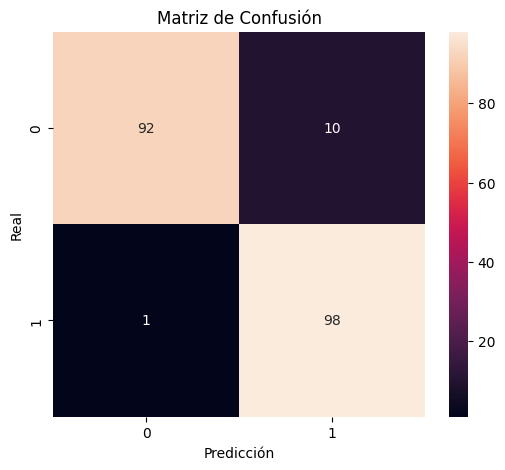

In [16]:
print("\nEvaluando modelo...\n")

model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        outputs = model(images)

        _, predicted = torch.max(outputs.data, 1)

        y_true.extend(labels.tolist())
        y_pred.extend(predicted.cpu().tolist())

acc = accuracy_score(y_true, y_pred)
print(f"\nAccuracy total: {acc*100:.2f}%\n")

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Normal", "Dañada"]))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

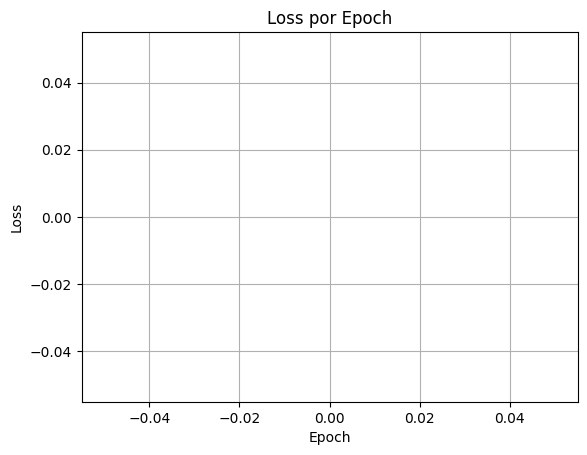

In [17]:
plt.plot(loss_values)
plt.title("Loss por Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()

In [12]:
from PIL import Image
import torch
import torchvision.transforms as transforms

# -----------------------------
# TRANSFORMACIÓN (MISMA QUE EN EL TRAINING)
# -----------------------------
predict_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# -----------------------------
# FUNCIÓN DE PREDICCIÓN
# -----------------------------
def predict_image(image_path, model, device):
    model.eval()

    # Cargar imagen
    img = Image.open(image_path).convert("L")  # Convertir a escala de grises si tu modelo usa 1 canal

    # Aplicar transformaciones
    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs).item()

    clases = ["Normal", "Dañada"]

    print("\n📌 **Resultado de la predicción**")
    print("Imagen:", image_path)
    print("Predicción:", clases[pred_class])
    print(f"Probabilidades → Normal: {probs[0][0]:.4f} | Dañada: {probs[0][1]:.4f}")

    return clases[pred_class]



In [13]:
image_path = r"C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN\cartaDañada-026.png"
predict_image(image_path, model, device)


📌 **Resultado de la predicción**
Imagen: C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN\cartaDañada-026.png
Predicción: Dañada
Probabilidades → Normal: 0.0075 | Dañada: 0.9925


'Dañada'

In [14]:
from PIL import Image
import torch
import torchvision.transforms as transforms

# -----------------------------
# TRANSFORMACIÓN (MISMA QUE EN EL TRAINING)
# -----------------------------
predict_transform = transforms.Compose([
    transforms.Resize((227, 227)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])


# -----------------------------
# FUNCIÓN: predecir UNA imagen
# -----------------------------
def predict_image(image_path, model, device):
    model.eval()

    img = Image.open(image_path).convert("L")  # 1 canal porque AlexNet fue modificado
    img_tensor = predict_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        probs = torch.softmax(output, dim=1)
        pred_class = torch.argmax(probs).item()

    clases = ["Normal", "Dañada"]

    print(f"\n📌 Imagen: {image_path}")
    print(f"Predicción: {clases[pred_class]}")
    print(f"Probabilidades → Normal: {probs[0][0]:.4f} | Dañada: {probs[0][1]:.4f}")

    return clases[pred_class]


# ------------------------------------------------
# FUNCIÓN: predecir VARIAS imágenes (lista paths)
# ------------------------------------------------
def predict_multiple(images_paths, model, device):
    print("\n========== RESULTADOS DE PREDICCIÓN ==========\n")

    results = {}
    for path in images_paths:
        result = predict_image(path, model, device)
        results[path] = result
    
    print("\n==============================================\n")
    return results


In [15]:
images = [
    r"C:\Users\Sebastian\Desktop\PruebaModelAlexNet\normalN-20251125T140847Z-1-001\normalN\carta-270.jpg",
    r"C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN\cartaDañada-125.png"
]

predict_multiple(images, model, device)


========== RESULTADOS DE PREDICCIÓN ==========


📌 Imagen: C:\Users\Sebastian\Desktop\PruebaModelAlexNet\normalN-20251125T140847Z-1-001\normalN\carta-270.jpg
Predicción: Normal
Probabilidades → Normal: 0.9483 | Dañada: 0.0517

📌 Imagen: C:\Users\Sebastian\Desktop\PruebaModelAlexNet\dañadasN-20251125T140818Z-1-001\dañadasN\cartaDañada-125.png
Predicción: Dañada
Probabilidades → Normal: 0.0020 | Dañada: 0.9980




{'C:\\Users\\Sebastian\\Desktop\\PruebaModelAlexNet\\normalN-20251125T140847Z-1-001\\normalN\\carta-270.jpg': 'Normal',
 'C:\\Users\\Sebastian\\Desktop\\PruebaModelAlexNet\\dañadasN-20251125T140818Z-1-001\\dañadasN\\cartaDañada-125.png': 'Dañada'}

In [19]:
# -----------------------------
# GUARDAR MODELO (solo pesos)
# -----------------------------
model_path = "alexnet_cards_weights.pth"
torch.save(model.state_dict(), model_path)
print(f"Modelo guardado correctamente en: {model_path}")

Modelo guardado correctamente en: alexnet_cards_weights.pth
